# Feature Engineering — SSH Anomaly Detection

Notebook này thực hiện quá trình **chuẩn bị dữ liệu** từ session-level CSV
(output của bước EDA + labeling) thành dataset sẵn sàng cho ML training.

**Nội dung:**
1. Load dữ liệu session-level
2. Giải thích từng feature — tại sao giữ, tại sao bỏ
3. Biến đổi features (edge case handling, log transform)
4. Kiểm tra chất lượng features (distribution, correlation, discriminative power)
5. Train / Test split (Stratified K-Fold + Time-based holdout)
6. Xuất dataset train-ready

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

from feature_engineering import (
    load_session_csv, prepare_features, describe_features,
    TRAINING_FEATURES, CLASS_NAMES, TARGET,
    _DROP_ALWAYS, _DROP_DEFAULT,
)

SESSION_CSV = '../data/processed/ssh_sessions.csv'
OUTPUT_DIR  = '../data/processed'

---
## 1. Load dữ liệu Session-level

Dữ liệu đầu vào là file `ssh_sessions.csv` — mỗi row là **1 session SSH**
(nhóm theo IP, tách bằng idle gap 10 phút).

In [2]:
df = load_session_csv(SESSION_CSV)
print(f'Dataset shape: {df.shape}')
print(f'Columns ({len(df.columns)}): {list(df.columns)}')
df.head()

Dataset shape: (3916, 19)
Columns (19): ['ip', 'is_private', 'total_attempts', 'session_duration', 'attempts_per_second', 'is_single_event', 'total_failures', 'total_successes', 'failure_ratio', 'unique_users_count', 'unique_users_ratio', 'has_root_attempt', 'has_valid_user_attempt', 'max_failure_streak', 'invalid_user_attempts', 'has_reverse_mapping_failed', 'ts_first', 'ts_last', 'class']


,ip,is_private,total_attempts,session_duration,attempts_per_second,is_single_event,total_failures,total_successes,failure_ratio,unique_users_count,unique_users_ratio,has_root_attempt,has_valid_user_attempt,max_failure_streak,invalid_user_attempts,has_reverse_mapping_failed,ts_first,ts_last,class
0,173.234.31.186,0,2,2,0.666667,0,2,0,1.0,1,0.5,0,0,2,2,1,1702166146,1702166148,1
1,173.234.31.186,0,2,2,0.666667,0,2,0,1.0,1,0.5,0,0,2,2,1,1702166908,1702166910,1
2,52.80.34.196,0,2,7,0.250000,0,2,0,1.0,1,0.5,0,0,2,2,0,1702166858,1702166865,1
3,52.80.34.196,0,2,7,0.250000,0,2,0,1.0,1,0.5,0,0,2,2,0,1702169755,1702169762,1
4,52.80.34.196,0,2,7,0.250000,0,2,0,1.0,1,0.5,0,0,2,2,0,1702172660,1702172667,1


In [3]:
df.info()
print()
df.describe().round(3)

<class 'pandas.DataFrame'>
RangeIndex: 3916 entries, 0 to 3915
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ip                          3916 non-null   str    
 1   is_private                  3916 non-null   int64  
 2   total_attempts              3916 non-null   int64  
 3   session_duration            3916 non-null   int64  
 4   attempts_per_second         3916 non-null   float64
 5   is_single_event             3916 non-null   int64  
 6   total_failures              3916 non-null   int64  
 7   total_successes             3916 non-null   int64  
 8   failure_ratio               3916 non-null   float64
 9   unique_users_count          3916 non-null   int64  
 10  unique_users_ratio          3916 non-null   float64
 11  has_root_attempt            3916 non-null   int64  
 12  has_valid_user_attempt      3916 non-null   int64  
 13  max_failure_streak          3916 non-null   

,is_private,total_attempts,session_duration,attempts_per_second,is_single_event,total_failures,total_successes,failure_ratio,unique_users_count,unique_users_ratio,has_root_attempt,has_valid_user_attempt,max_failure_streak,invalid_user_attempts,has_reverse_mapping_failed,ts_first,ts_last,class
count,3916.000,3916.000,3916.000,3916.000,3916.000,3916.000,3916.000,3916.000,3916.000,3916.000,3916.000,3916.000,3916.000,3916.000,3916.000,3.916000e+03,3.916000e+03,3916.000
mean,0.000,54.175,254.433,0.531,0.081,54.128,0.046,0.966,2.534,0.469,0.299,0.037,54.128,54.122,0.132,1.703132e+09,1.703132e+09,1.563
std,0.016,713.752,3909.669,0.274,0.273,713.756,0.279,0.178,6.979,0.218,0.458,0.188,713.756,713.756,0.339,7.231273e+05,7.233876e+05,0.932
min,0.000,1.000,0.000,0.002,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,1.702166e+09,1.702166e+09,0.000
25%,0.000,2.000,2.000,0.277,0.000,2.000,0.000,1.000,1.000,0.400,0.000,0.000,2.000,2.000,0.000,1.702570e+09,1.702570e+09,1.000
50%,0.000,2.000,3.000,0.538,0.000,2.000,0.000,1.000,1.000,0.500,0.000,0.000,2.000,2.000,0.000,1.702927e+09,1.702927e+09,1.000
75%,0.000,7.000,14.000,0.667,0.000,7.000,0.000,1.000,1.000,0.500,1.000,0.000,7.000,7.000,0.000,1.703852e+09,1.703852e+09,3.000
max,1.000,28766.000,180953.000,2.000,1.000,28766.000,6.000,1.000,158.000,1.000,1.000,1.000,28766.000,28766.000,1.000,1.704623e+09,1.704623e+09,4.000


---
## 2. Giải thích Feature Selection

Session CSV chứa **19 cột** (18 features + 1 target). Không phải tất cả đều
phù hợp cho ML training — một số bị **data leakage**, một số là **metadata**.

### Nguyên tắc chọn feature

1. **Không leak nhãn** — feature không được "tiết lộ" luật gán nhãn
2. **Tính tổng quát** — feature phải generalize, không phải memorize
3. **Không redundant** — ưu tiên ratio hơn count tuyệt đối

In [4]:
# Feature decision table
feature_decisions = [
    ('ip',                        'Drop',    'Identity',      'Categorical metadata — quá nhiều unique values, không encode được'),
    ('is_private',                'KEEP',    'Identity',      'Binary — phân biệt IP nội bộ vs Internet'),
    ('total_attempts',            'Drop',    'Volume',        'Correlated với duration & ratios — dễ gây overfitting'),
    ('session_duration',          'KEEP',    'Volume',        'Thời lượng session — log1p transform do skew cao'),
    ('attempts_per_second',       'KEEP',    'Volume',        'Tốc độ tấn công — log1p transform, zero-out cho single events'),
    ('is_single_event',           'KEEP',    'Volume',        'Binary — cô lập sessions 1 event (không đủ context)'),
    ('total_failures',            'Drop',    'Ratios',        '⚠️ LEAK — failure count gần = total_attempts cho most classes'),
    ('total_successes',           'Drop',    'Ratios',        '⚠️ LEAK — total_successes > 0 gần ≡ class 4 (Break-in)'),
    ('failure_ratio',             'KEEP',    'Ratios',        'Tỉ lệ failure — cốt lõi, không leak count tuyệt đối'),
    ('unique_users_count',        'Drop',    'Ratios',        'Redundant — đã có unique_users_ratio'),
    ('unique_users_ratio',        'KEEP',    'Ratios',        'Tỉ lệ user unique — zero-out cho single events (1/1=1 mimics scan)'),
    ('has_root_attempt',          'KEEP',    'Boolean Agg.',  'Binary — nhắm vào root = nguy hiểm'),
    ('has_valid_user_attempt',    'KEEP',    'Boolean Agg.',  'Binary — attacker có thông tin nội bộ'),
    ('max_failure_streak',        'KEEP',    'Boolean Agg.',  'Chuỗi fail liên tục per-session — log1p transform'),
    ('invalid_user_attempts',     'KEEP',    'Boolean Agg.',  'Số lần thử user không hợp lệ per-session — log1p transform'),
    ('has_reverse_mapping_failed','KEEP',    'Cybersecurity', 'Binary — DNS anomaly, dấu hiệu botnet/giả mạo'),
    ('ts_first',                  'Drop',    'Metadata',      'Timestamp — metadata, không phải feature'),
    ('ts_last',                   'Drop',    'Metadata',      'Timestamp — metadata, không phải feature'),
]

decisions_df = pd.DataFrame(feature_decisions, columns=['Feature', 'Decision', 'Group', 'Lý do'])
decisions_df

,Feature,Decision,Group,Lý do
0,ip,Drop,Identity,Categorical metadata — quá nhiều unique values...
1,is_private,KEEP,Identity,Binary — phân biệt IP nội bộ vs Internet
2,total_attempts,Drop,Volume,Correlated với duration & ratios — dễ gây over...
3,session_duration,KEEP,Volume,Thời lượng session — log1p transform do skew cao
4,attempts_per_second,KEEP,Volume,"Tốc độ tấn công — log1p transform, zero-out ch..."
5,is_single_event,KEEP,Volume,Binary — cô lập sessions 1 event (không đủ con...
6,total_failures,Drop,Ratios,⚠️ LEAK — failure count gần = total_attempts c...
7,total_successes,Drop,Ratios,⚠️ LEAK — total_successes > 0 gần ≡ class 4 (B...
8,failure_ratio,KEEP,Ratios,"Tỉ lệ failure — cốt lõi, không leak count tuyệ..."
9,unique_users_count,Drop,Ratios,Redundant — đã có unique_users_ratio


In [5]:
# Show data leakage evidence
print('=== Evidence: tại sao Drop total_failures & total_successes ===\n')

print('total_failures vs class:')
for cls in sorted(df['class'].unique()):
    subset = df[df['class'] == cls]
    all_fail = (subset['total_failures'] == subset['total_attempts']).mean()
    print(f'  Class {cls} ({CLASS_NAMES[cls]:15s}): {all_fail:.1%} sessions có total_failures = total_attempts')

print('\ntotal_successes vs class:')
for cls in sorted(df['class'].unique()):
    subset = df[df['class'] == cls]
    has_success = (subset['total_successes'] > 0).mean()
    print(f'  Class {cls} ({CLASS_NAMES[cls]:15s}): {has_success:.1%} sessions có total_successes > 0')

print('\n→ total_successes > 0 gần ≡ class 0 hoặc 4 — LEAK!')
print('→ total_failures = total_attempts gần ≡ class 1/2/3 — LEAK!')

=== Evidence: tại sao Drop total_failures & total_successes ===

total_failures vs class:
  Class 0 (Normal         ): 0.0% sessions có total_failures = total_attempts
  Class 1 (Single failure ): 100.0% sessions có total_failures = total_attempts
  Class 2 (Scan           ): 99.5% sessions có total_failures = total_attempts
  Class 3 (Brute-force    ): 100.0% sessions có total_failures = total_attempts
  Class 4 (Break-in       ): 0.0% sessions có total_failures = total_attempts

total_successes vs class:
  Class 0 (Normal         ): 100.0% sessions có total_successes > 0
  Class 1 (Single failure ): 0.0% sessions có total_successes > 0
  Class 2 (Scan           ): 0.5% sessions có total_successes > 0
  Class 3 (Brute-force    ): 0.0% sessions có total_successes > 0
  Class 4 (Break-in       ): 100.0% sessions có total_successes > 0

→ total_successes > 0 gần ≡ class 0 hoặc 4 — LEAK!
→ total_failures = total_attempts gần ≡ class 1/2/3 — LEAK!


---
## 3. Biến đổi Features

### 3.1 Phân tích distribution TRƯỚC transform

Một số features có phân bố **skew cực cao** (long-tail), cần log transform.

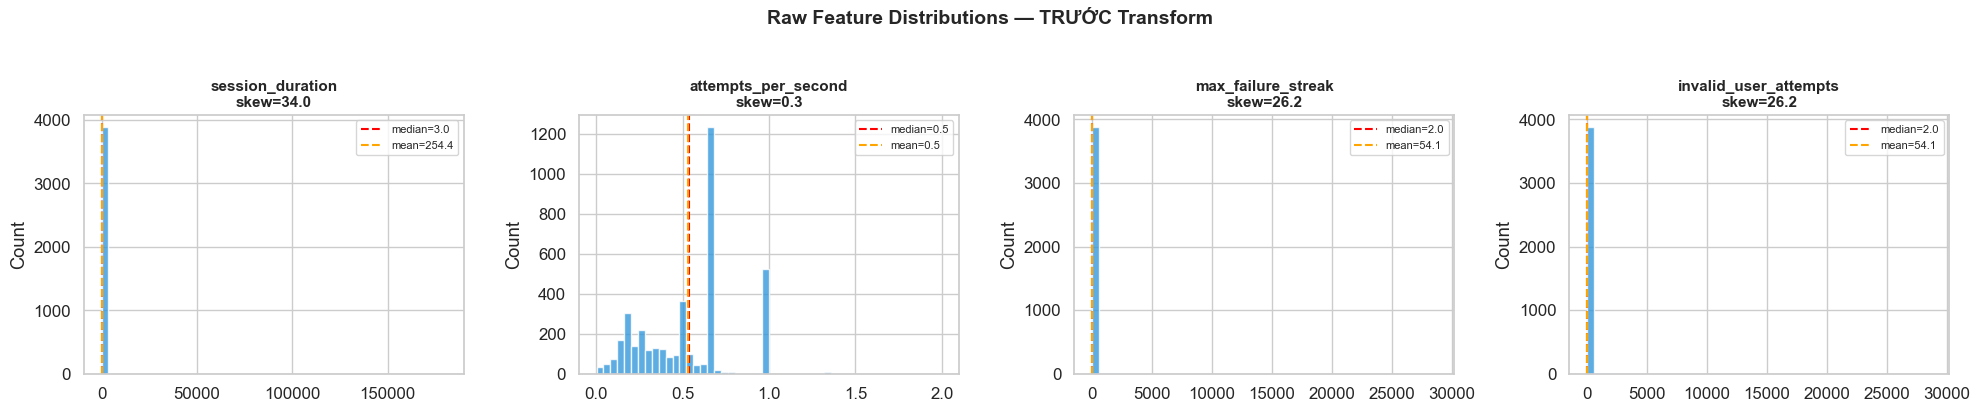

All 4 features trên sẽ được log1p transform.


In [6]:
# Show skewness of raw features
skew_cols = ['session_duration', 'attempts_per_second', 'max_failure_streak', 'invalid_user_attempts']

fig, axes = plt.subplots(1, len(skew_cols), figsize=(20, 4))
for ax, col in zip(axes, skew_cols):
    vals = df[col]
    ax.hist(vals, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
    ax.set_title(f'{col}\nskew={vals.skew():.1f}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Count')
    ax.axvline(vals.median(), color='red', linestyle='--', label=f'median={vals.median():.1f}')
    ax.axvline(vals.mean(), color='orange', linestyle='--', label=f'mean={vals.mean():.1f}')
    ax.legend(fontsize=8)

plt.suptitle('Raw Feature Distributions — TRƯỚC Transform', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print('All 4 features trên sẽ được log1p transform.')

### 3.2 Áp dụng Transforms

`prepare_features()` thực hiện 3 bước theo thứ tự:

1. **Feature selection** — drop 7 cột (metadata + leak + redundant)

2. **Edge case handling** (trước transform):
   - `attempts_per_second = 0` khi `is_single_event = 1` (session 1 event: `1/(0+1) = 1` vô nghĩa)
   - `unique_users_ratio = 0` khi `is_single_event = 1` (session 1 event: `1/1 = 1.0` giống scan)

3. **`log1p(x)`** cho `session_duration`, `attempts_per_second`, `max_failure_streak`, `invalid_user_attempts`
   — giảm skew, giữ thứ tự, log1p(0) = 0

In [7]:
# Apply transforms
X, y = prepare_features(df)

print(f'Input:  {df.shape[1]} columns → Output: {X.shape[1]} features + 1 target')
print(f'Dropped: {[c for c in df.columns if c not in list(X.columns) + [TARGET]]}')
print(f'\nFinal features ({X.shape[1]}):')
for i, col in enumerate(X.columns, 1):
    dtype = 'binary' if X[col].nunique() <= 2 else 'continuous'
    transform = ''
    if col in ['session_duration', 'attempts_per_second', 'max_failure_streak', 'invalid_user_attempts']:
        transform = ' [log1p]'
    print(f'  {i:2d}. {col:30s} {dtype:12s}{transform}')

Input:  19 columns → Output: 11 features + 1 target
Dropped: ['ip', 'total_attempts', 'total_failures', 'total_successes', 'unique_users_count', 'ts_first', 'ts_last']

Final features (11):
   1. is_private                     binary      
   2. session_duration               continuous   [log1p]
   3. attempts_per_second            continuous   [log1p]
   4. is_single_event                binary      
   5. failure_ratio                  continuous  
   6. unique_users_ratio             continuous  
   7. has_root_attempt               binary      
   8. has_valid_user_attempt         binary      
   9. max_failure_streak             continuous   [log1p]
  10. invalid_user_attempts          continuous   [log1p]
  11. has_reverse_mapping_failed     binary      


In [8]:
# Edge case verification
single = X[X['is_single_event'] == 1]
print(f'Sessions with is_single_event=1: {len(single)}')
print(f'  attempts_per_second values: {single["attempts_per_second"].unique()}  ← zeroed out')
print(f'  unique_users_ratio values:  {single["unique_users_ratio"].unique()}  ← zeroed out')
print(f'\n→ is_single_event=1 đã encode đầy đủ, ratio/speed = 0 để tránh mislead model')

Sessions with is_single_event=1: 318
  attempts_per_second values: [0.]  ← zeroed out
  unique_users_ratio values:  [0.]  ← zeroed out

→ is_single_event=1 đã encode đầy đủ, ratio/speed = 0 để tránh mislead model


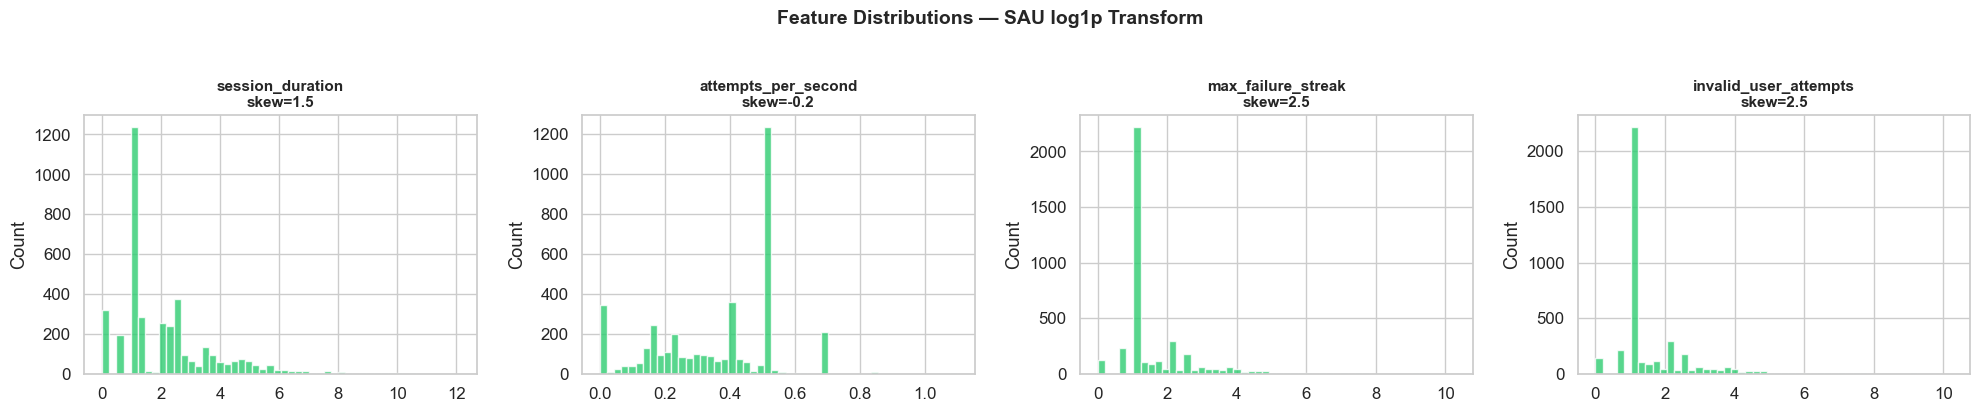

In [9]:
# Show distributions AFTER transform
transform_cols = ['session_duration', 'attempts_per_second', 'max_failure_streak', 'invalid_user_attempts']

fig, axes = plt.subplots(1, len(transform_cols), figsize=(20, 4))
for ax, col in zip(axes, transform_cols):
    vals = X[col]
    ax.hist(vals, bins=50, color='#2ecc71', edgecolor='white', alpha=0.8)
    ax.set_title(f'{col}\nskew={vals.skew():.1f}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('Feature Distributions — SAU log1p Transform', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

---
## 4. Kiểm tra chất lượng Features

### 4.1 Discriminative Power — Feature means per class

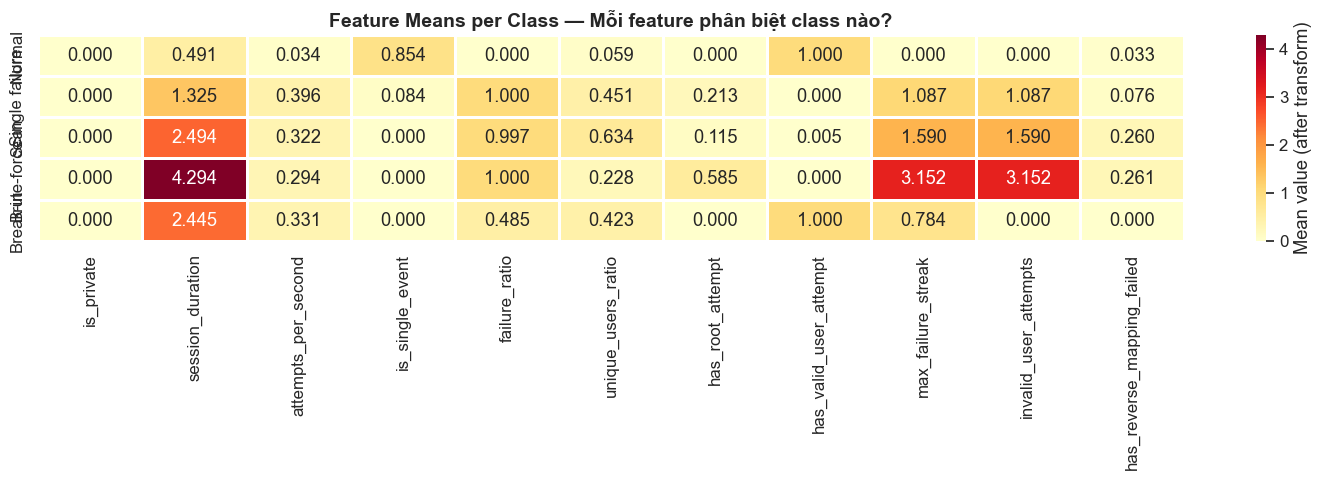

In [10]:
# Heatmap: mean feature value per class
summary = describe_features(X, y)
mean_cols = [c for c in summary.columns if c.endswith('_mean')]
heatmap_data = summary.set_index('label')[mean_cols].copy()
heatmap_data.columns = [c.replace('_mean', '') for c in mean_cols]

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(heatmap_data.astype(float), annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.8, ax=ax, cbar_kws={'label': 'Mean value (after transform)'})
ax.set_title('Feature Means per Class — Mỗi feature phân biệt class nào?',
             fontsize=14, fontweight='bold')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [11]:
# Key discriminative patterns
print('=== Discriminative Power Analysis ===\n')

analysis = [
    ('failure_ratio',
     'Normal=0, Attack~1 → phân biệt Normal vs tất cả attack classes'),
    ('unique_users_ratio',
     'Scan có ratio cao (nhiều user) vs Brute-force (ít user, đánh nhiều lần)'),
    ('max_failure_streak',
     'Brute-force có streak rất cao → dấu hiệu tool tự động liên tục'),
    ('invalid_user_attempts',
     'Brute-force dồn dập user không hợp lệ, Normal/Break-in ~ 0'),
    ('has_reverse_mapping_failed',
     'Normal=3% vs Scan/BF=26% → cybersecurity context, botnet/proxy'),
    ('has_root_attempt',
     'Brute-force nhắm root nhiều nhất → mức độ nguy hiểm'),
    ('has_valid_user_attempt',
     'Break-in có valid user attempt → attacker biết username thật'),
    ('attempts_per_second',
     'Tool tự động có speed cao → phân biệt automated vs manual'),
]

for feat, explanation in analysis:
    values = [f'{heatmap_data.loc[CLASS_NAMES[c], feat]:.3f}' for c in range(5)]
    print(f'  {feat}')
    print(f'    Values: N={values[0]}  SF={values[1]}  Sc={values[2]}  BF={values[3]}  BI={values[4]}')
    print(f'    -> {explanation}\n')

=== Discriminative Power Analysis ===

  failure_ratio
    Values: N=0.000  SF=1.000  Sc=0.997  BF=1.000  BI=0.485
    -> Normal=0, Attack~1 → phân biệt Normal vs tất cả attack classes

  unique_users_ratio
    Values: N=0.059  SF=0.451  Sc=0.634  BF=0.228  BI=0.423
    -> Scan có ratio cao (nhiều user) vs Brute-force (ít user, đánh nhiều lần)

  max_failure_streak
    Values: N=0.000  SF=1.087  Sc=1.590  BF=3.152  BI=0.784
    -> Brute-force có streak rất cao → dấu hiệu tool tự động liên tục

  invalid_user_attempts
    Values: N=0.000  SF=1.087  Sc=1.590  BF=3.152  BI=0.000
    -> Brute-force dồn dập user không hợp lệ, Normal/Break-in ~ 0

  has_reverse_mapping_failed
    Values: N=0.033  SF=0.076  Sc=0.260  BF=0.261  BI=0.000
    -> Normal=3% vs Scan/BF=26% → cybersecurity context, botnet/proxy

  has_root_attempt
    Values: N=0.000  SF=0.213  Sc=0.115  BF=0.585  BI=0.000
    -> Brute-force nhắm root nhiều nhất → mức độ nguy hiểm

  has_valid_user_attempt
    Values: N=1.000  SF=0.

### 4.2 Feature Distributions by Class

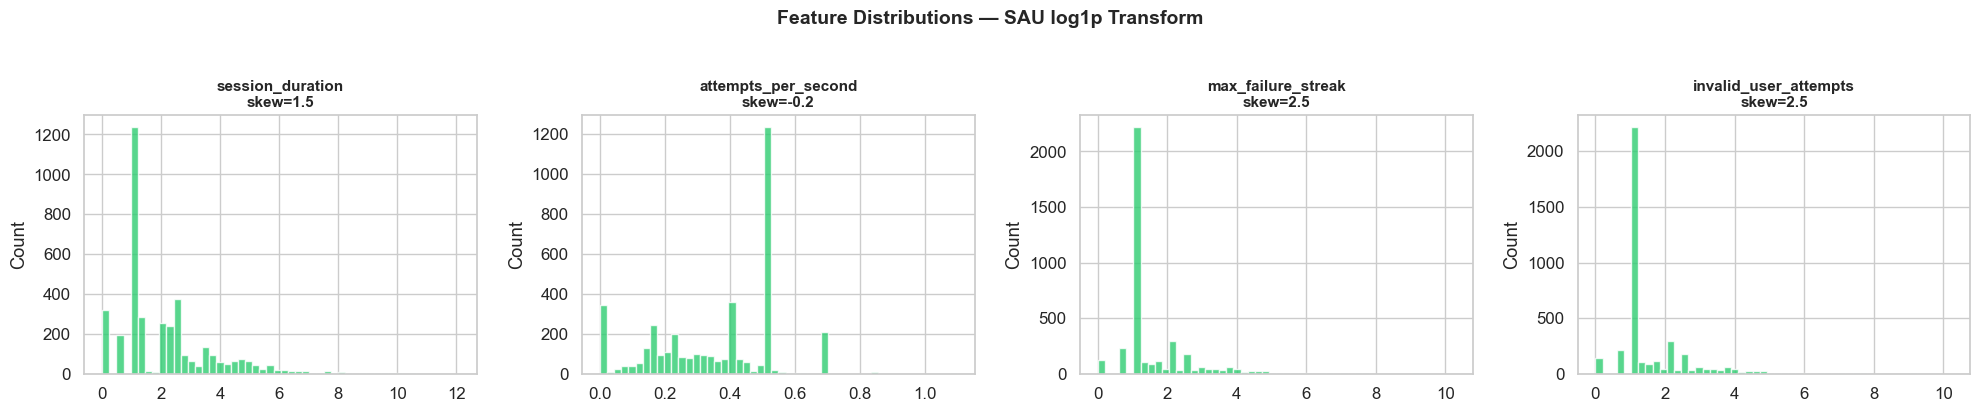

In [12]:
# Box plots per class for continuous features
continuous_feats = ['session_duration', 'attempts_per_second', 'failure_ratio',
                    'unique_users_ratio', 'max_failure_streak', 'invalid_user_attempts']

combined = X.copy()
combined['class_label'] = y.map(CLASS_NAMES)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
order = [CLASS_NAMES[i] for i in range(5)]
class_colors = {CLASS_NAMES[i]: c for i, c in enumerate(['#2ecc71', '#f39c12', '#3498db', '#e74c3c', '#8e44ad'])}

for ax, feat in zip(axes.flatten(), continuous_feats):
    sns.boxplot(data=combined, x='class_label', y=feat, order=order,
                palette=class_colors, ax=ax, fliersize=2)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Feature Distributions by Class', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

C:\Users\phong\AppData\Local\Temp\ipykernel_33648\226386906.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x='class_label', y=feat, order=order,
C:\Users\phong\AppData\Local\Temp\ipykernel_33648\226386906.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x='class_label', y=feat, order=order,
C:\Users\phong\AppData\Local\Temp\ipykernel_33648\226386906.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x='class_label', y=feat, order=order,
C:\Users\phong\AppData\Local\Temp\ipykernel_33648

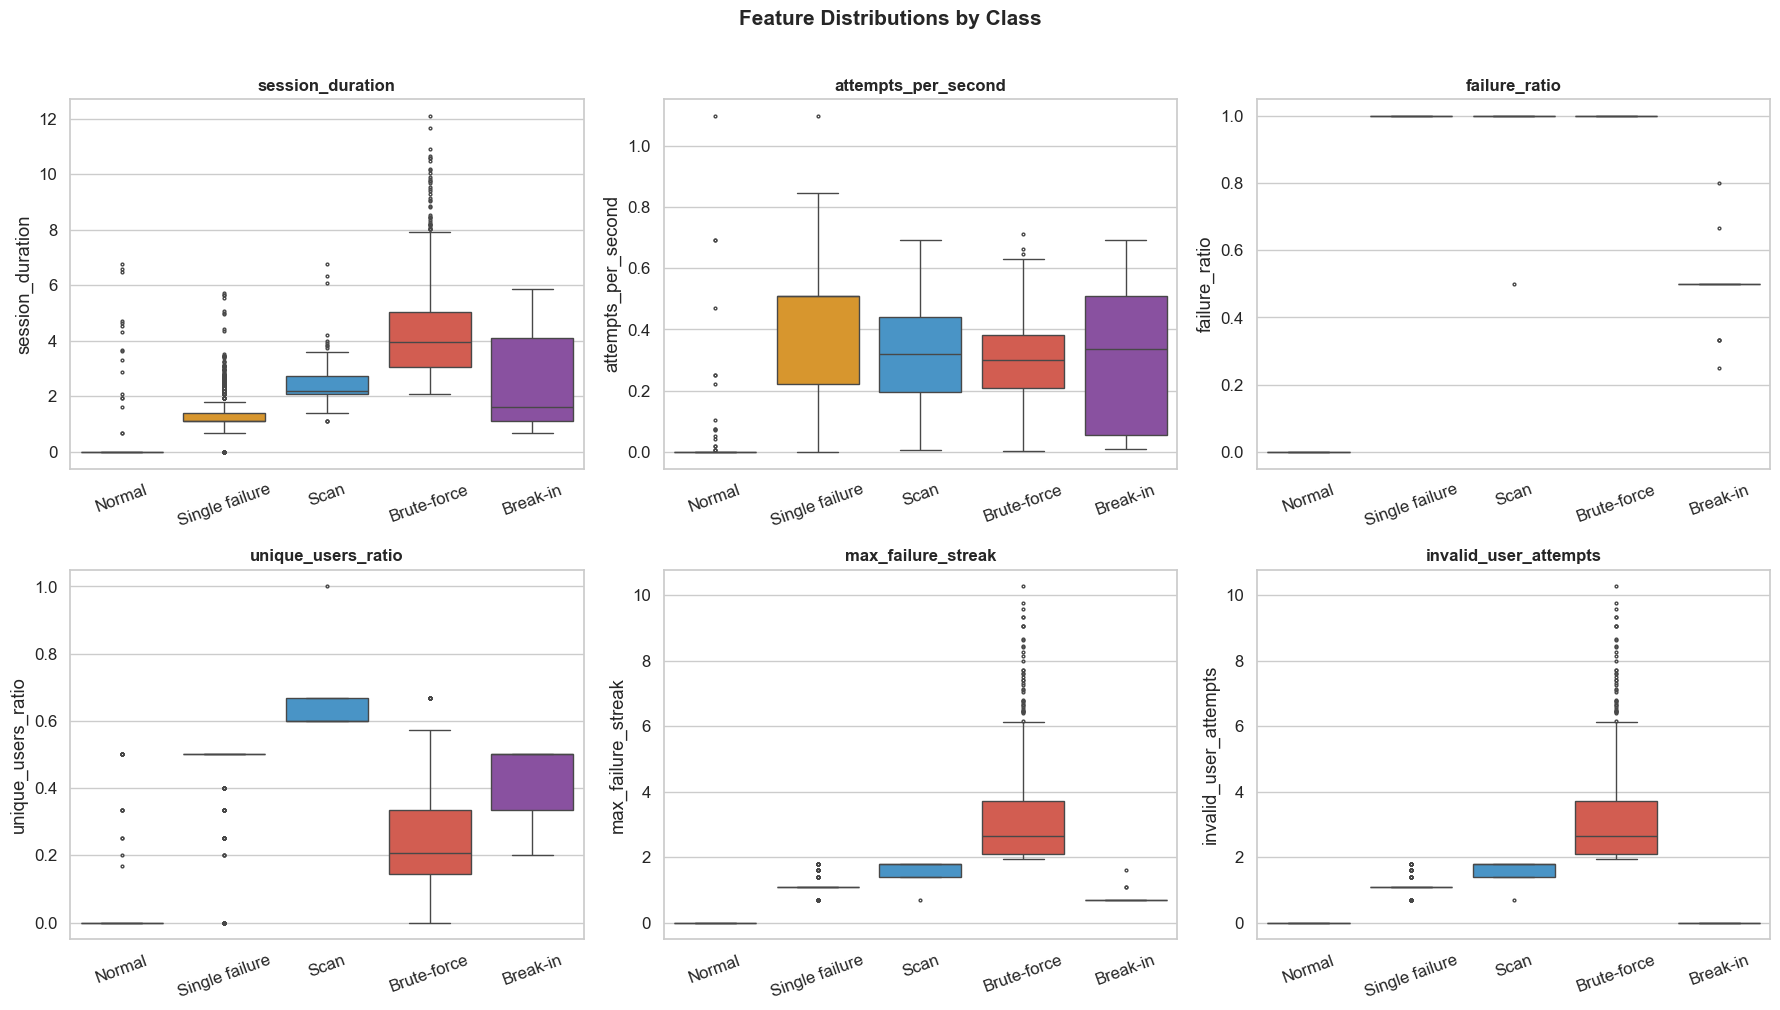

In [13]:
# Binary features: proportions per class
binary_feats = ['is_private', 'is_single_event', 'has_root_attempt',
                'has_valid_user_attempt', 'has_reverse_mapping_failed']

fig, axes = plt.subplots(1, len(binary_feats), figsize=(20, 4))

for ax, feat in zip(axes, binary_feats):
    proportions = []
    for cls in range(5):
        subset = X[y == cls]
        proportions.append(subset[feat].mean())

    colors = ['#2ecc71', '#f39c12', '#3498db', '#e74c3c', '#8e44ad']
    bars = ax.bar([CLASS_NAMES[i] for i in range(5)], proportions, color=colors)
    for bar, val in zip(bars, proportions):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.0%}', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.tick_params(axis='x', rotation=30, labelsize=8)

plt.suptitle('Binary Feature Proportions by Class', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 4.3 Feature Correlation

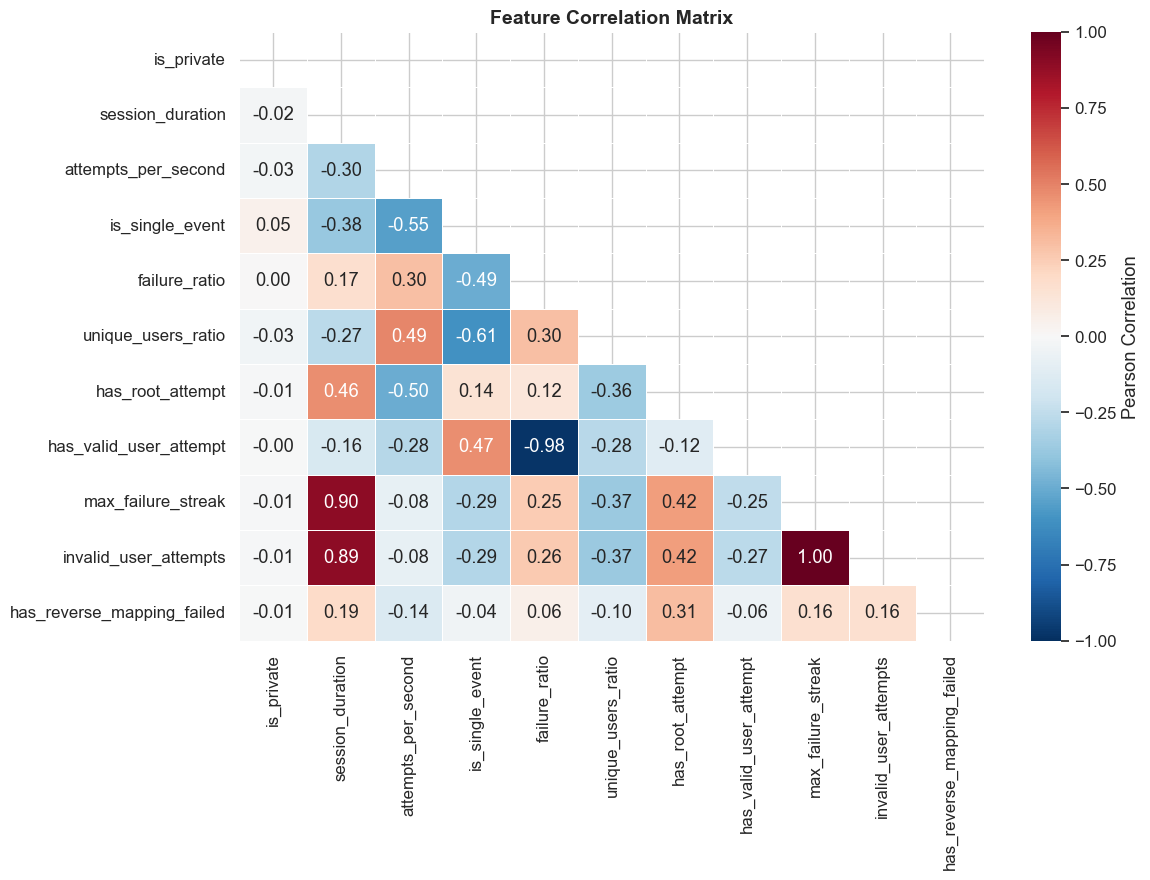

Feature pairs with |correlation| > 0.4:
  max_failure_streak             <-> invalid_user_attempts         : +0.999  ⚠️ Xem xét
  failure_ratio                  <-> has_valid_user_attempt        : -0.982  ⚠️ Xem xét
  session_duration               <-> max_failure_streak            : +0.898  ⚠️ Xem xét
  session_duration               <-> invalid_user_attempts         : +0.894  ⚠️ Xem xét
  is_single_event                <-> unique_users_ratio            : -0.607  ✅ Chấp nhận
  attempts_per_second            <-> is_single_event               : -0.550  ✅ Chấp nhận
  attempts_per_second            <-> has_root_attempt              : -0.499  ✅ Chấp nhận
  is_single_event                <-> failure_ratio                 : -0.495  ✅ Chấp nhận
  attempts_per_second            <-> unique_users_ratio            : +0.488  ✅ Chấp nhận
  is_single_event                <-> has_valid_user_attempt        : +0.465  ✅ Chấp nhận
  session_duration               <-> has_root_attempt              : +0.46

In [14]:
# Correlation matrix
fig, ax = plt.subplots(figsize=(12, 9))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# List high correlations
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) > 0.4:
            high_corr.append((corr.columns[i], corr.columns[j], val))

print('Feature pairs with |correlation| > 0.4:')
for f1, f2, c in sorted(high_corr, key=lambda x: -abs(x[2])):
    risk = '  ⚠️ Xem xét' if abs(c) > 0.7 else '  ✅ Chấp nhận'
    print(f'  {f1:30s} <-> {f2:30s}: {c:+.3f}{risk}')

if not high_corr:
    print('  Không có — features rất độc lập! ✅')

---
## 5. Train / Test Split

### Chiến lược split

| Method | Mục đích | Lý do |
|--------|---------|-------|
| **Stratified 5-Fold CV** | Chọn model + tune hyperparameters | Class thiểu số (Scan và Break-in chỉ vài chục sessions) cần stratify để mỗi fold có đủ mẫu |
| **Time-based holdout** | Đánh giá cuối cùng (1 lần duy nhất) | Simulate deployment thực tế: train past, test future |

**Tại sao không chỉ dùng train/test split đơn?**

- Scan chỉ 192 sessions, Break-in chỉ 19 → split 80/20 cho test set chỉ ~4 Break-in
- Một lần split "xui" có thể khiến precision/recall = 0 hoàn toàn
- K-Fold CV cho kết quả ổn định hơn (trung bình 5 lần)

In [15]:
from sklearn.model_selection import StratifiedKFold

# --- Stratified K-Fold CV ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('=== Stratified 5-Fold CV ===\n')
for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]
    train_dist = y_train_fold.value_counts().sort_index()
    val_dist = y_val_fold.value_counts().sort_index()
    print(f'Fold {fold_idx}: train={len(train_idx)}, val={len(val_idx)}')
    for cls in range(5):
        t = train_dist.get(cls, 0)
        v = val_dist.get(cls, 0)
        print(f'    {cls} {CLASS_NAMES[cls]:15s}: train={t:>5}, val={v:>4}')
    print()

=== Stratified 5-Fold CV ===

Fold 1: train=3132, val=784
    0 Normal         : train=   98, val=  25
    1 Single failure : train= 2033, val= 509
    2 Scan           : train=  154, val=  38
    3 Brute-force    : train=  832, val= 208
    4 Break-in       : train=   15, val=   4

Fold 2: train=3133, val=783
    0 Normal         : train=   98, val=  25
    1 Single failure : train= 2033, val= 509
    2 Scan           : train=  154, val=  38
    3 Brute-force    : train=  832, val= 208
    4 Break-in       : train=   16, val=   3

Fold 3: train=3133, val=783
    0 Normal         : train=   99, val=  24
    1 Single failure : train= 2034, val= 508
    2 Scan           : train=  153, val=  39
    3 Brute-force    : train=  832, val= 208
    4 Break-in       : train=   15, val=   4

Fold 4: train=3133, val=783
    0 Normal         : train=   99, val=  24
    1 Single failure : train= 2034, val= 508
    2 Scan           : train=  153, val=  39
    3 Brute-force    : train=  832, val= 208


In [16]:
# --- Time-based holdout ---
# Train: ngày 1-21 (75%), Test: ngày 22-28 (25%)
# Dùng ts_first từ raw session data để split theo thời gian

ts_first = df['ts_first']
ts_min, ts_max = ts_first.min(), ts_first.max()
ts_range = ts_max - ts_min
ts_cutoff = ts_min + ts_range * 0.75  # 75% time point

time_train_mask = ts_first <= ts_cutoff
time_test_mask = ts_first > ts_cutoff

X_time_train = X[time_train_mask]
X_time_test = X[time_test_mask]
y_time_train = y[time_train_mask]
y_time_test = y[time_test_mask]

print('=== Time-based Holdout (75/25 by timestamp) ===\n')
print(f'Train: {len(X_time_train):,} sessions (ngày 1-21)')
print(f'Test:  {len(X_time_test):,} sessions (ngày 22-28)\n')

print(f'{"Class":<20} {"Train":>8} {"Test":>8} {"Test %":>8}')
print('-' * 48)
for cls in range(5):
    t = (y_time_train == cls).sum()
    v = (y_time_test == cls).sum()
    pct = v / (t + v) * 100 if (t + v) > 0 else 0
    print(f'{cls} {CLASS_NAMES[cls]:17s} {t:>8} {v:>8} {pct:>7.1f}%')

print(f'\n⚠️ Time-based split có thể làm class thiểu số biến mất khỏi test set')
print(f'→ Dùng CV để chọn model, holdout chỉ để đánh giá cuối cùng')

# Automatic warning for small test classes
MIN_TEST_SAMPLES = 10
print()
print('Class size warnings (time-based test set):')
warned = False
for cls in range(5):
    count = (y_time_test == cls).sum()
    if count < MIN_TEST_SAMPLES:
        print(f'  class={cls} ({CLASS_NAMES[cls]}): only {count} samples -> metrics unreliable')
        warned = True
if not warned:
    print('  All classes have sufficient samples')


=== Time-based Holdout (75/25 by timestamp) ===

Train: 3,107 sessions (ngày 1-21)
Test:  809 sessions (ngày 22-28)

Class                   Train     Test   Test %
------------------------------------------------
0 Normal                  65       58    47.2%
1 Single failure        2198      344    13.5%
2 Scan                   145       47    24.5%
3 Brute-force            687      353    33.9%
4 Break-in                12        7    36.8%

⚠️ Time-based split có thể làm class thiểu số biến mất khỏi test set
→ Dùng CV để chọn model, holdout chỉ để đánh giá cuối cùng

Class size warnings (time-based test set):
  class=4 (Break-in): only 7 samples -> metrics unreliable


---
## 6. Xuất Dataset Train-ready

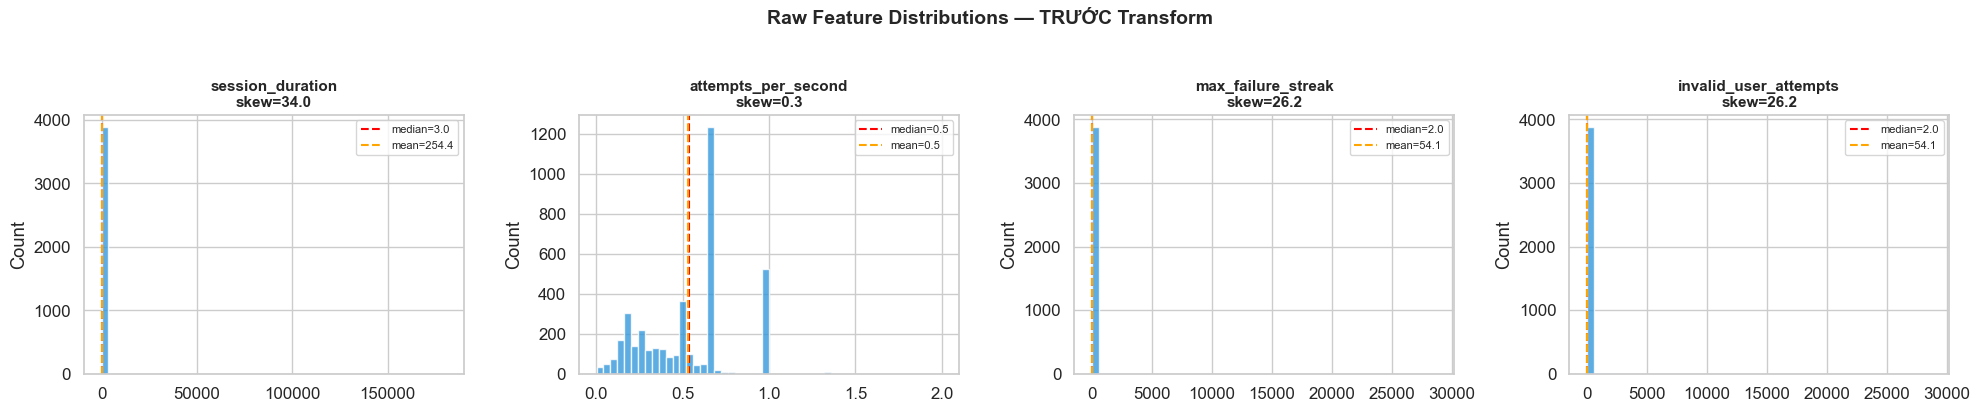

All 4 features trên sẽ được log1p transform.


In [17]:
# Pre-export validation
print('=== Pre-export Validation ===\n')

missing = X.isnull().sum().sum()
print(f'Missing values:  {missing}', '✅' if missing == 0 else '❌')

infs = np.isinf(X.select_dtypes(include=[np.number])).sum().sum()
print(f'Infinite values: {infs}', '✅' if infs == 0 else '❌')

print(f'\nFeature ranges:')
for col in X.columns:
    print(f'  {col:30s}: [{X[col].min():>8.3f}, {X[col].max():>8.3f}]')

print(f'\nClass distribution:')
for cls in sorted(y.unique()):
    count = (y == cls).sum()
    pct = count / len(y) * 100
    print(f'  {cls} {CLASS_NAMES[cls]:17s}: {count:>5,} ({pct:5.2f}%)')

In [18]:
from pathlib import Path

output_dir = Path(OUTPUT_DIR)

# Export full dataset (features + target)
X_path = output_dir / 'X_train_ready.csv'
X.to_csv(X_path, index=False)
print(f'Features saved: {X_path}  shape={X.shape}')

y_path = output_dir / 'y_train_ready.csv'
y.to_csv(y_path, index=False, header=True)
print(f'Target saved:   {y_path}  shape={y.shape}')

# Export time-based splits
X_time_train.to_csv(output_dir / 'X_time_train.csv', index=False)
y_time_train.to_csv(output_dir / 'y_time_train.csv', index=False, header=True)
X_time_test.to_csv(output_dir / 'X_time_test.csv', index=False)
y_time_test.to_csv(output_dir / 'y_time_test.csv', index=False, header=True)
print(f'\nTime splits saved:')
print(f'  Train: X_time_train.csv ({X_time_train.shape}), y_time_train.csv')
print(f'  Test:  X_time_test.csv ({X_time_test.shape}), y_time_test.csv')

# Reload test
X_reload = pd.read_csv(X_path)
y_reload = pd.read_csv(y_path).squeeze()
assert X_reload.shape == X.shape, 'Feature shape mismatch!'
assert len(y_reload) == len(y), 'Target length mismatch!'
print(f'\n✅ Reload test passed — data integrity confirmed')

=== Pre-export Validation ===

Missing values:  0 ✅
Infinite values: 0 ✅

Feature ranges:
  is_private                    : [   0.000,    1.000]
  session_duration              : [   0.000,   12.106]
  attempts_per_second           : [   0.000,    1.099]
  is_single_event               : [   0.000,    1.000]
  failure_ratio                 : [   0.000,    1.000]
  unique_users_ratio            : [   0.000,    1.000]
  has_root_attempt              : [   0.000,    1.000]
  has_valid_user_attempt        : [   0.000,    1.000]
  max_failure_streak            : [   0.000,   10.267]
  invalid_user_attempts         : [   0.000,   10.267]
  has_reverse_mapping_failed    : [   0.000,    1.000]

Class distribution:
  0 Normal           :   123 ( 3.14%)
  1 Single failure   : 2,542 (64.91%)
  2 Scan             :   192 ( 4.90%)
  3 Brute-force      : 1,040 (26.56%)
  4 Break-in         :    19 ( 0.49%)


---
## Tổng kết

### Pipeline Feature Engineering

```
ssh_sessions.csv (19 cols)
  → Feature Selection (drop 7)
  → Edge Case Handling (zero-out single events)
  → Log Transform (4 skewed features)
  → X_train_ready.csv (11 features) + y_train_ready.csv (target 0-4)
  → X/y_time_train.csv + X/y_time_test.csv
```

### 11 Features cuối cùng

| # | Feature | Type | Transform | Signal |
|---|---------|------|-----------|--------|
| 1 | `is_private` | Binary | — | IP nội bộ vs Internet |
| 2 | `session_duration` | Continuous | log1p | Thời lượng tấn công |
| 3 | `attempts_per_second` | Continuous | zero-out + log1p | Tốc độ tool tự động |
| 4 | `is_single_event` | Binary | — | Isolate session 1 event |
| 5 | `failure_ratio` | Continuous | — | Normal vs Attack |
| 6 | `unique_users_ratio` | Continuous | zero-out | Scan vs Brute-force |
| 7 | `has_root_attempt` | Binary | — | Mức độ nguy hiểm |
| 8 | `has_valid_user_attempt` | Binary | — | Insider knowledge |
| 9 | `max_failure_streak` | Continuous | log1p | Brute-force intensity |
| 10 | `invalid_user_attempts` | Continuous | log1p | Account scan depth |
| 11 | `has_reverse_mapping_failed` | Binary | — | DNS anomaly (cybersec) |

### Chiến lược Train/Test

| Method | Dùng khi | Files |
|--------|---------|-------|
| Stratified 5-Fold CV | Chọn model + tune | `X/y_train_ready.csv` |
| Time-based holdout | Đánh giá cuối | `X/y_time_train.csv` + `X/y_time_test.csv` |

### Lưu ý cho Training

- Dùng `class_weight='balanced'` — class imbalance (Normal 3.1%, Break-in 0.5%)
- Features đã transform — **không cần** StandardScaler cho tree-based models
- Nếu dùng linear models (SVM, Logistic Regression) — **cần** StandardScaler thêm
- CV dùng `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`

In [19]:
# Final dataset preview
print('=== X_train_ready.csv (first 10 rows) ===')
X.head(10)

=== X_train_ready.csv (first 10 rows) ===


,is_private,session_duration,attempts_per_second,is_single_event,failure_ratio,unique_users_ratio,has_root_attempt,has_valid_user_attempt,max_failure_streak,invalid_user_attempts,has_reverse_mapping_failed
0,0,1.098612,0.510826,0,1.0,0.5,0,0,1.098612,1.098612,1
1,0,1.098612,0.510826,0,1.0,0.5,0,0,1.098612,1.098612,1
2,0,2.079442,0.223144,0,1.0,0.5,0,0,1.098612,1.098612,0
3,0,2.079442,0.223144,0,1.0,0.5,0,0,1.098612,1.098612,0
4,0,2.079442,0.223144,0,1.0,0.5,0,0,1.098612,1.098612,0
5,0,2.079442,0.223144,0,1.0,0.5,0,0,1.098612,1.098612,0
6,0,2.197225,0.200671,0,1.0,0.5,0,0,1.098612,1.098612,0
7,0,2.079442,0.223144,0,1.0,0.5,0,0,1.098612,1.098612,0
8,0,1.098612,0.510826,0,1.0,0.5,0,0,1.098612,1.098612,0
9,0,2.079442,0.223144,0,1.0,0.5,0,0,1.098612,1.098612,0
